**24BAD130 Vishal S**

**SCENARIO 1 – K-NEAREST NEIGHBORS (KNN)**

Problem Statement
Predict whether a tumor is benign or malignant based on medical measurements.

Dataset (Kaggle – Public)
Breast Cancer Dataset
Dataset Link: https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset

Target Variable: Diagnosis (Benign / Malignant)
Input Feature:
• Radius
• Texture
• Perimeter
• Area
• Smoothness

IN-LAB TASKS (KNN Classification)
1.	Import required Python libraries.
2.	Load the Breast Cancer dataset.
3.	Perform data inspection & preprocessing.
4.	Encode target labels.
5.	Apply feature scaling (very important for KNN).
6.	Split dataset into training and testing sets.
7.	Train a KNN classifier.
8.	Experiment with different values of K.
9.	Predict diagnosis labels.
10.	Evaluate performance using:
• Accuracy
• Precision / Recall / F1 Score
11.	Identify misclassified cases.
12.	Analyze model sensitivity to K.

Visualization
• Confusion Matrix
• Accuracy vs K Plot
• Decision Boundary (using two features)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("breast-cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df.drop(columns=['id'], inplace=True, errors='ignore')

In [ ]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [ ]:
X = df[['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean']]
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
k_values = range(1,21)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9298245614035088
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



In [ ]:
misclassified = X_test[y_test != y_pred]
print("Misclassified samples:", len(misclassified))

Misclassified samples: 8


In [ ]:
mask = y_test != y_pred
misclassified = X_test[mask]

print(misclassified)

[[ 0.97777802 -0.98659467  0.94865013  0.85383059  0.15013907]
 [-0.0929555  -0.8143917  -0.06339309 -0.20133147  0.30883801]
 [-0.16963933 -1.94301926 -0.1671924  -0.27214963  2.32993656]
 [ 0.13993614  1.10078455  0.10713434  0.02221499 -0.47113524]
 [-0.2889253   0.75637861 -0.20385168 -0.35690389  0.27325529]
 [-0.05319351 -1.42408329 -0.06833592 -0.17260604  2.02392516]
 [ 0.46939261 -0.3257076   0.47908184  0.35867233  0.05264242]
 [-0.04751323 -0.52118124 -0.02220289 -0.1492844   0.94221044]]


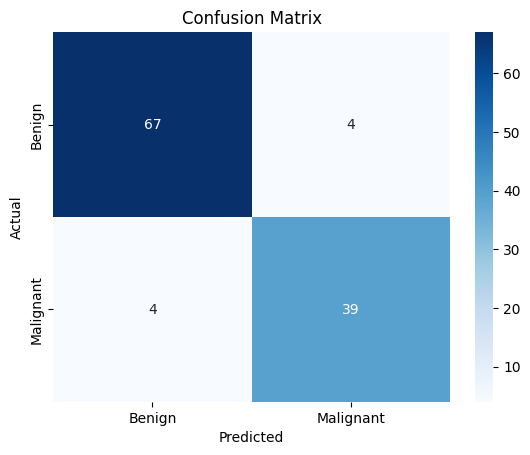

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

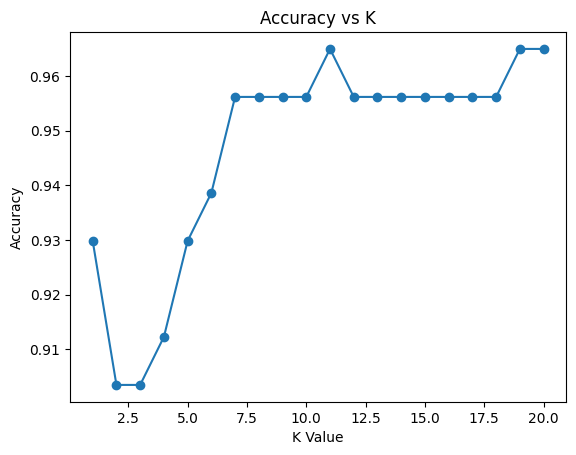

In [ ]:
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

In [ ]:
best_k = 5   # or any value you want
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d, y_train_2d)

KNeighborsClassifier()

In [ ]:
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_2d, y_train_2d)
    y_pred = model.predict(X_test_2d)
    scores.append(accuracy_score(y_test_2d, y_pred))

best_k = k_values[scores.index(max(scores))]
print("Best k:", best_k)

Best k: 10


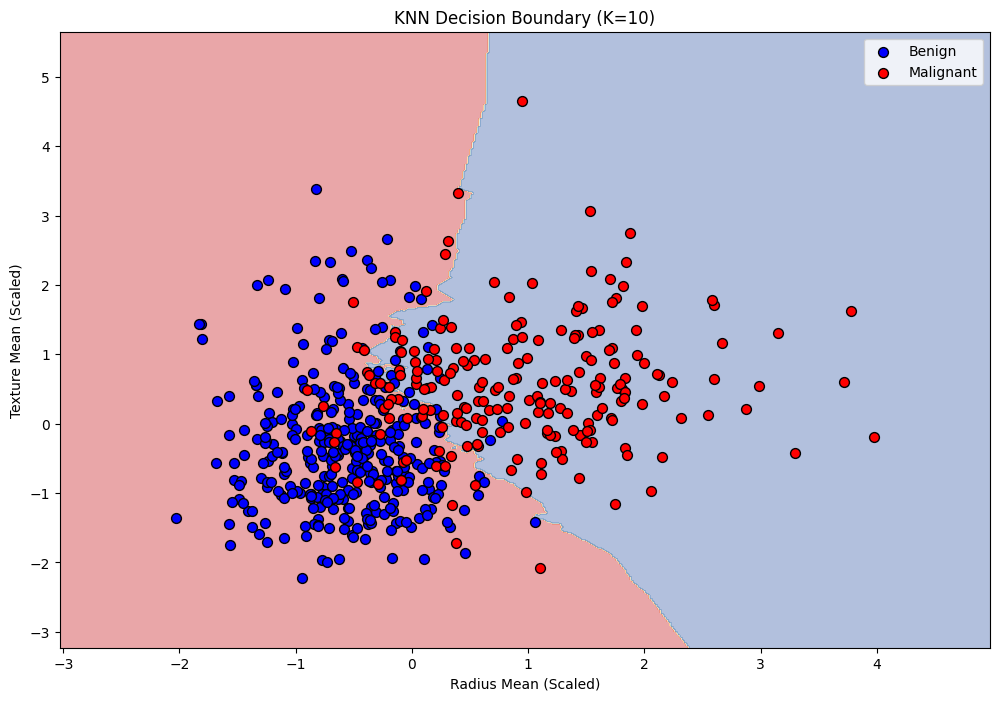

Decision boundary visualization completed!


In [ ]:
X_2d = df[['radius_mean', 'texture_mean']].values
X_2d_scaled = StandardScaler().fit_transform(X_2d)

# Split data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d_scaled, y, test_size=0.2, random_state=42
)

# Train model
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d, y_train_2d)

# Create mesh grid
h = 0.02  # step size
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on mesh
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
plt.scatter(X_2d_scaled[y==0, 0], X_2d_scaled[y==0, 1],
           c='blue', label='Benign', edgecolors='k', s=50)
plt.scatter(X_2d_scaled[y==1, 0], X_2d_scaled[y==1, 1],
           c='red', label='Malignant', edgecolors='k', s=50)
plt.xlabel('Radius Mean (Scaled)')
plt.ylabel('Texture Mean (Scaled)')
plt.title(f'KNN Decision Boundary (K={best_k})')
plt.legend()
plt.show()

print("Decision boundary visualization completed!")

**SCENARIO 2 – DECISION TREE CLASSIFIER**

Problem Statement
Predict whether a loan application should be approved or rejected.

Dataset (Public / Standard Dataset)
Loan Prediction Dataset
Dataset Link: https://www.kaggle.com/datasets/ninzaami/loan-predication

Target Variable: Loan Status (Approved / Rejected)
Input Features
• Applicant Income
• Loan Amount
• Credit History
• Education
• Property Area

IN-LAB TASKS (Decision Tree Classification)
1.	Import required Python libraries.
2.	Load the Loan Prediction dataset.
3.	Perform preprocessing:
• Handle missing values
• Encode categorical variables
4.	Split dataset into training and testing sets.
5.	Train a Decision Tree classifier.
6.	Experiment with tree depth / pruning.
7.	Predict loan status.
8.	Evaluate performance using:
• Accuracy
• Precision / Recall / F1 Score
9.	Analyze feature importance.
10.	Detect overfitting behavior.
11.	Compare shallow vs deep trees.

Visualization
• Confusion Matrix
• Tree Structure Plot
• Feature Importance Plot


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df['ApplicantIncome'].fillna(df['ApplicantIncome'].median(), inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Education'].fillna(df['Education'].mode()[0], inplace=True)
df['Property_Area'].fillna(df['Property_Area'].mode()[0], inplace=True)
df['Loan_Status'].fillna(df['Loan_Status'].mode()[0], inplace=True)

df.isnull().sum()

/tmp/ipython-input-294/1568292348.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ApplicantIncome'].fillna(df['ApplicantIncome'].median(), inplace=True)
/tmp/ipython-input-294/1568292348.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,14


In [ ]:
X = df[['ApplicantIncome', 'LoanAmount', 'Credit_History',
        'Education', 'Property_Area']]

y = df['Loan_Status']

In [ ]:
le = LabelEncoder()

X['Education'] = le.fit_transform(X['Education'])
X['Property_Area'] = le.fit_transform(X['Property_Area'])
y = le.fit_transform(y)

/tmp/ipython-input-294/2022827043.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Education'] = le.fit_transform(X['Education'])
/tmp/ipython-input-294/2022827043.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Property_Area'] = le.fit_transform(X['Property_Area'])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7235772357723578

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.51      0.56        43
           1       0.76      0.84      0.80        80

    accuracy                           0.72       123
   macro avg       0.69      0.67      0.68       123
weighted avg       0.71      0.72      0.72       123



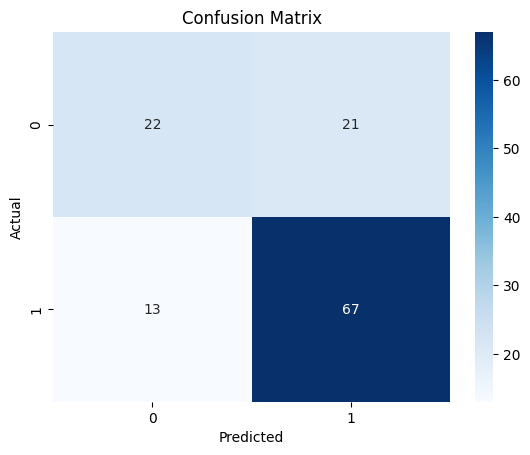

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
depths = [2, 3, 5, 10, None]
train_acc = []
test_acc = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dt.predict(X_test)))
for i in range(len(depths)):
    print(f"Depth: {depths[i]}, Train Acc: {train_acc[i]}, Test Acc: {test_acc[i]}")

Depth: 2, Train Acc: 0.814663951120163, Test Acc: 0.7886178861788617
Depth: 3, Train Acc: 0.824847250509165, Test Acc: 0.7560975609756098
Depth: 5, Train Acc: 0.8513238289205702, Test Acc: 0.7642276422764228
Depth: 10, Train Acc: 0.9389002036659878, Test Acc: 0.7398373983739838
Depth: None, Train Acc: 1.0, Test Acc: 0.7235772357723578


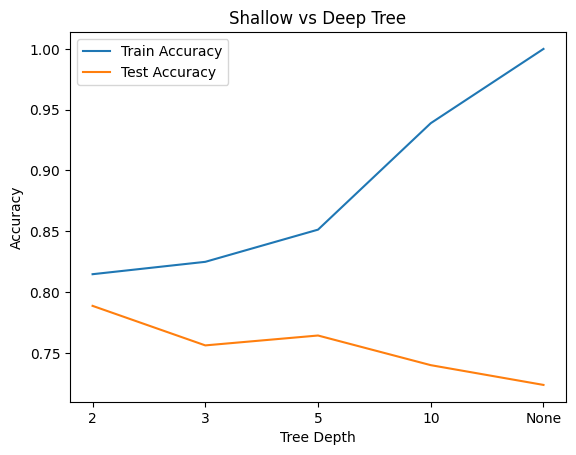

In [ ]:
plt.plot([str(d) for d in depths], train_acc, label='Train Accuracy')
plt.plot([str(d) for d in depths], test_acc, label='Test Accuracy')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Shallow vs Deep Tree")
plt.legend()
plt.show()

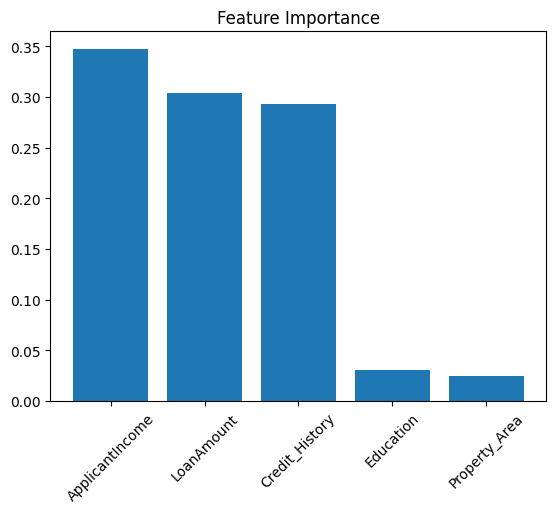

In [ ]:

importance = model.feature_importances_
features = X.columns
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

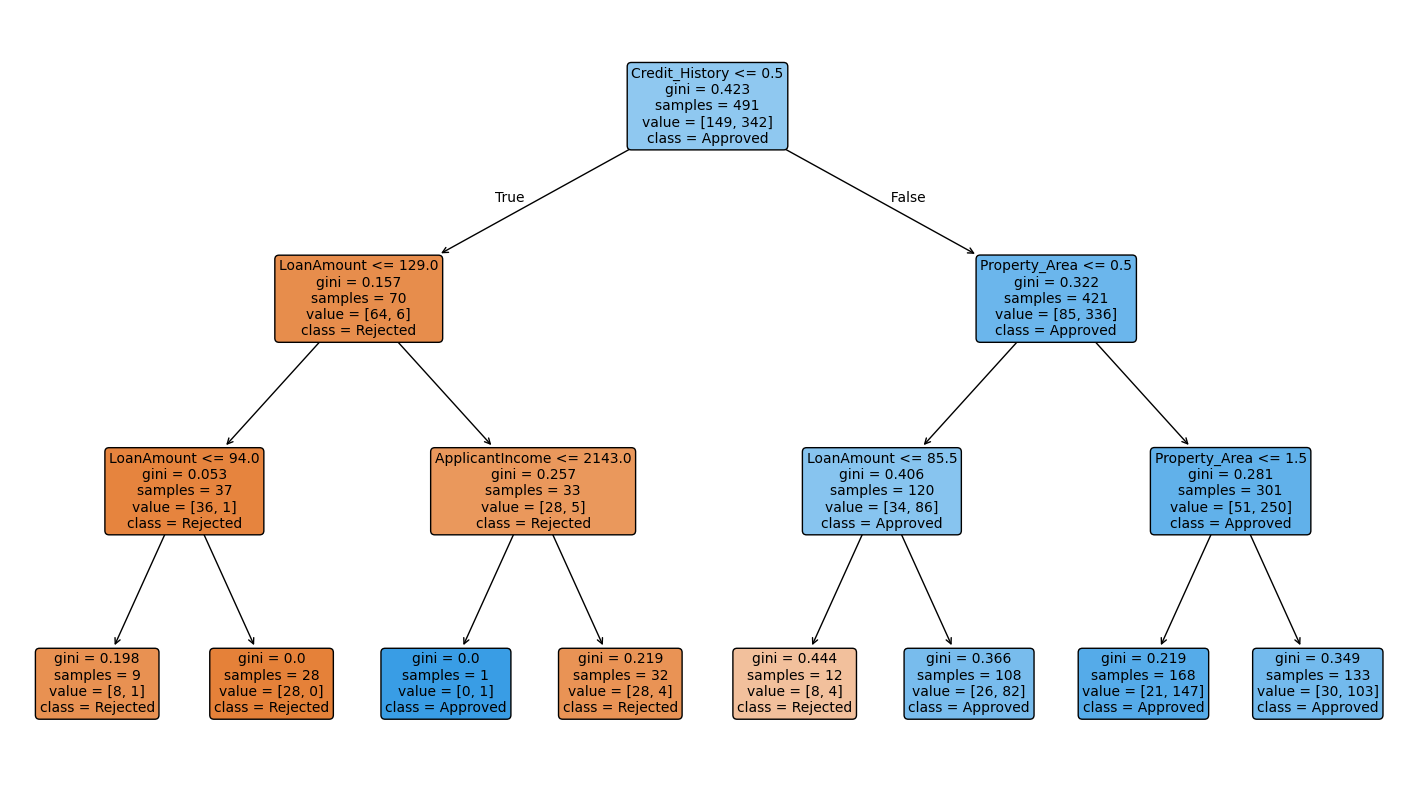

In [ ]:
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(18,10))
plot_tree(small_tree,
          feature_names=X.columns,
          class_names=["Rejected","Approved"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()